In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Librerias

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop, Adam, SGD, Nadam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf

import json

import pickle

from itertools import combinations


#Ruta para guardar/importar archivos

In [71]:
ruta='/content/drive/MyDrive/Colab Notebooks/Tesis/Codigos/'

#Impartamos base de datos sinteticos

In [72]:
data_reshaped=np.load(ruta+'data_reshaped.npy')

In [73]:
data_reshaped.shape

(13989, 13, 1)

#Importar parametros

In [74]:
with open(ruta+"periodo.json") as f:
    config = json.load(f)

inicio = config["inicio"]
final = config["final"]

##Separamos base de datos

In [75]:
#Dividir en train y temp (train 70%, temp 30%)
train_data, temp_data = train_test_split(data_reshaped, test_size=0.3, random_state=94)

#Dividir temp en validation y test (cada uno 15% del total)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=94)

print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(9792, 13, 1)
(2098, 13, 1)
(2099, 13, 1)


In [76]:
#Entrenamiento
x_total_train=train_data[:,:inicio,:]
y_total_train=train_data[:,inicio:,:]

#Validacion
x_total_valid=val_data[:,:inicio,:]
y_total_valid=val_data[:,inicio:,:]

#Test
x_total_test=test_data[:,:inicio,:]
y_total_test=test_data[:,inicio:,:]

#Imprimo
print("Entranamiento:",x_total_train.shape,y_total_train.shape)
print("Validacion:",x_total_valid.shape,y_total_valid.shape)
print("Test:",x_total_test.shape,y_total_test.shape)

Entranamiento: (9792, 10, 1) (9792, 3, 1)
Validacion: (2098, 10, 1) (2098, 3, 1)
Test: (2099, 10, 1) (2099, 3, 1)


#Red neuronal

In [77]:
# Ajustar parámetros para reproducibilidad del entrenamiento
tf.random.set_seed(159)
tf.config.experimental.enable_op_determinism()

In [78]:
#@title Funcion
def entrenar_modelo_1(
    x_total_train,
    y_total_train,
    x_total_valid,
    y_total_valid,
    output_length,
    N_UNITS_1,
    N_UNITS_2,
    N_UNITS_3,
    dropout,
    learning_rate,
    dense_units_1,
    dense_units_2,
    EPOCHS,
    BATCH_SIZE
):

    INPUT_SHAPE = (x_total_train.shape[1], x_total_train.shape[2])

    # -------- MODELO --------
    modelo = Sequential()

    #modelo.add(Input(shape=INPUT_SHAPE))

    modelo.add(LSTM(N_UNITS_1, return_sequences=True, input_shape=INPUT_SHAPE))

    modelo.add(LSTM(N_UNITS_1))

    modelo.add(Dropout(dropout))

    #modelo.add(LSTM(N_UNITS_2, return_sequences=True))

    #modelo.add(Dropout(dropout))

    #modelo.add(LSTM(N_UNITS_3))

    #modelo.add(Dropout(dropout))

    modelo.add(Dense(dense_units_1, activation='tanh'))

    #modelo.add(Dropout(dropout))

    #modelo.add(Dense(dense_units_2, activation='tanh'))

    modelo.add(Dense(output_length, activation='linear'))

    # -------- LOSS --------
    def root_mean_squared_error(y_true, y_pred):
        rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred - y_true)))
        return rmse

    # -------- EARLY STOP --------
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    # -------- OPTIMIZER --------
    optimizador = RMSprop(learning_rate=learning_rate)

    modelo.compile(
        optimizer=optimizador,
        loss=root_mean_squared_error
    )

    # -------- TRAIN --------
    historia = modelo.fit(
        x=x_total_train,
        y=y_total_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_total_valid, y_total_valid),
        callbacks=[early_stop],
        verbose=2
    )

    return modelo, historia

In [79]:
input_length=inicio #10
output_length=final #3

celdas_lstm_1=128 #128
celdas_lstm_2=64 #64
celdas_lstm_3=32 #32
n_dropout=0.4 #0.3
tasa_aprednizj=5e-3 #5e-3
uni_dens_1=128 #128
uni_dens_2=64 #64
epoch=300 #300
batch=70 #350

In [80]:
modelo, historia = entrenar_modelo_1(
          x_total_train,
          y_total_train,
          x_total_valid,
          y_total_valid,
          output_length,
          N_UNITS_1=celdas_lstm_1,
          N_UNITS_2=celdas_lstm_2,
          N_UNITS_3=celdas_lstm_3,
          dropout=n_dropout,
          learning_rate=tasa_aprednizj,
          dense_units_1=uni_dens_1,
          dense_units_2=uni_dens_2,
          EPOCHS=epoch,
          BATCH_SIZE=batch
        )

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 - 2s - 18ms/step - loss: 0.4902 - val_loss: 0.3602
Epoch 2/300
140/140 - 1s - 6ms/step - loss: 0.3635 - val_loss: 0.2895
Epoch 3/300
140/140 - 1s - 6ms/step - loss: 0.3355 - val_loss: 0.2627
Epoch 4/300
140/140 - 1s - 6ms/step - loss: 0.3100 - val_loss: 0.2949
Epoch 5/300
140/140 - 1s - 8ms/step - loss: 0.2861 - val_loss: 0.2179
Epoch 6/300
140/140 - 1s - 10ms/step - loss: 0.2685 - val_loss: 0.1979
Epoch 7/300
140/140 - 1s - 9ms/step - loss: 0.2481 - val_loss: 0.1833
Epoch 8/300
140/140 - 1s - 8ms/step - loss: 0.2347 - val_loss: 0.1959
Epoch 9/300
140/140 - 1s - 6ms/step - loss: 0.2226 - val_loss: 0.1842
Epoch 10/300
140/140 - 1s - 6ms/step - loss: 0.2234 - val_loss: 0.1611
Epoch 11/300
140/140 - 1s - 6ms/step - loss: 0.2147 - val_loss: 0.1725
Epoch 12/300
140/140 - 1s - 6ms/step - loss: 0.2075 - val_loss: 0.1669
Epoch 13/300
140/140 - 1s - 6ms/step - loss: 0.2012 - val_loss: 0.1491
Epoch 14/300
140/140 - 1s - 6ms/step - loss: 0.1967 - val_loss: 0.1619
Epoch 15/300
140/140 - 1s

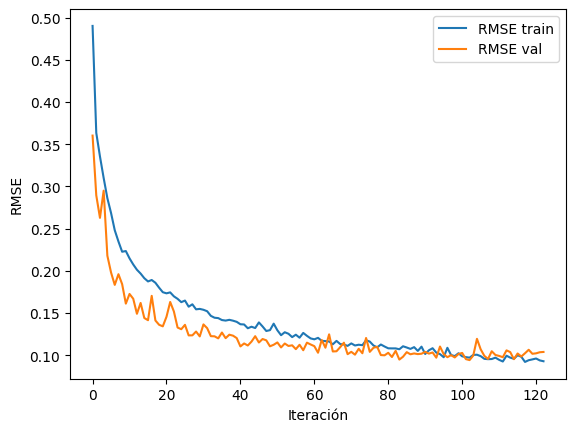

In [89]:
 # Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(historia.history['loss'],label='RMSE train')
plt.plot(historia.history['val_loss'],label='RMSE val')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend()
plt.savefig(ruta+'grafico_rmse.png', dpi=600)

plt.show()

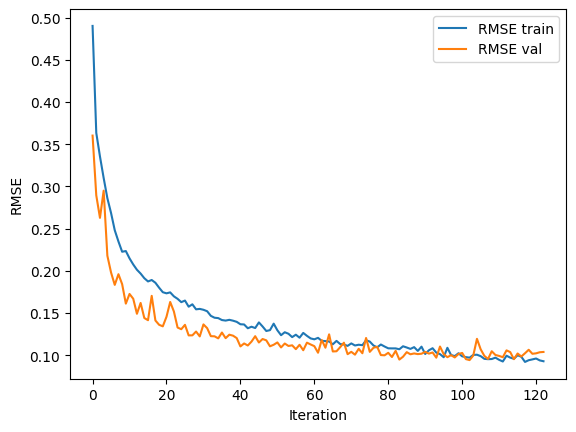

In [88]:
 # Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(historia.history['loss'],label='RMSE train')
plt.plot(historia.history['val_loss'],label='RMSE val')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.legend()
plt.savefig(ruta+'grafico_rmse_ingl.png', dpi=600)

plt.show()

In [82]:
# Cálculo de rmses para train, val y test
rmse_tr = modelo.evaluate(x=x_total_train, y=y_total_train, verbose=0)
rmse_vl = modelo.evaluate(x=x_total_valid, y=y_total_valid, verbose=0)
rmse_ts = modelo.evaluate(x=x_total_test, y=y_total_test, verbose=0)

# Imprimir resultados en pantalla
print('Comparativo desempeños:')
print(f'  RMSE train:\t {rmse_tr:.3f}')
print(f'  RMSE val:\t {rmse_vl:.3f}')
print(f'  RMSE test:\t {rmse_ts:.3f}')

Comparativo desempeños:
  RMSE train:	 0.075
  RMSE val:	 0.090
  RMSE test:	 0.082


#Guardar modelo

In [83]:
modelo.save(ruta+"modelo_lstm_sintc.keras")

#Guardar parametros

In [84]:
config = {
    "input_length": input_length,
    "output_length": output_length,
}

with open(ruta+"conf_sint.json", "w") as f:
    json.dump(config, f)


#Guardar historia

In [90]:
with open(ruta+"historial.json", "w") as f:
    json.dump(historia.history, f)

Importar historia

In [91]:
with open(ruta+"historial.json", "r") as f:
    history_loaded = json.load(f)

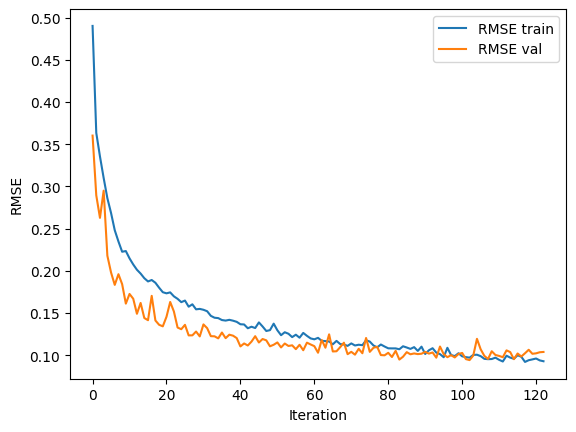

In [93]:
 # Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(history_loaded['loss'],label='RMSE train')
plt.plot(history_loaded['val_loss'],label='RMSE val')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.legend()
plt.savefig(ruta+'grafico_rmse_ingl.png', dpi=600)

plt.show()